In [4]:
import pandas as pd
import numpy as np

In [5]:
from google.colab import files
uploaded = files.upload()  # re-upload archive.zip fresh

import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

df = pd.read_csv('creditcard.csv')


# Sanity checks BEFORE doing anything else
assert df.shape == (284807, 31), f"Unexpected shape: {df.shape} — file may still be corrupted/truncated"
assert df.isnull().sum().sum() == 0, "NaNs present — file may still be corrupted/truncated"
print("✅ File verified:", df.shape, "| NaNs:", df.isnull().sum().sum())

df = df.sample(10000)

Saving archive.zip to archive (1).zip
✅ File verified: (284807, 31) | NaNs: 0


In [6]:
!git clone https://github.com/lukasz-galka-algorithms/optimized-deep-isolation-forest.git

Cloning into 'optimized-deep-isolation-forest'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 70 (delta 1), reused 3 (delta 1), pack-reused 61 (from 1)
Receiving objects: 100% (70/70), 42.88 MiB | 11.03 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (34/34), done.


In [7]:
import sys
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

In [8]:
sys.path.append("/content/optimized-deep-isolation-forest")
from algorithms.ODIF import DeepIF

In [9]:
feature_cols = [c for c in df.columns if c != "Class"]
X = df[feature_cols]
y = df["Class"]

print("Feature matrix:", X.shape)
print("Label distribution:", y.value_counts().to_dict())

Feature matrix: (10000, 30)
Label distribution: {0: 9977, 1: 23}


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Convert scaled numpy array to torch tensor — required
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

model = DeepIF(
    optimization=True,                      # True = ODIF (optimized), False = standard DIF
    representations_number=50,              # default is 50, lower = faster
    trees_per_representation=6,             # default is 6, lower = faster
    samples_number_per_tree=256,            # default is 256, lower = faster
    network_hidden_dimensions=[500],        # smaller network = faster
    representation_dimensionality=20,       # embedding output dimension
    batch_size=64,
    device='cpu',                           # IMPORTANT: change to 'cuda' if GPU runtime enabled
    seed=42
)

# Fit
model.fit(X_tensor)
print("Fitted")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fitted


In [12]:
# Get raw anomaly scores — higher = more anomalous
scores = model.decision_function(X_tensor)
df["anomaly_score"] = scores
print("Scores computed")

Scores computed


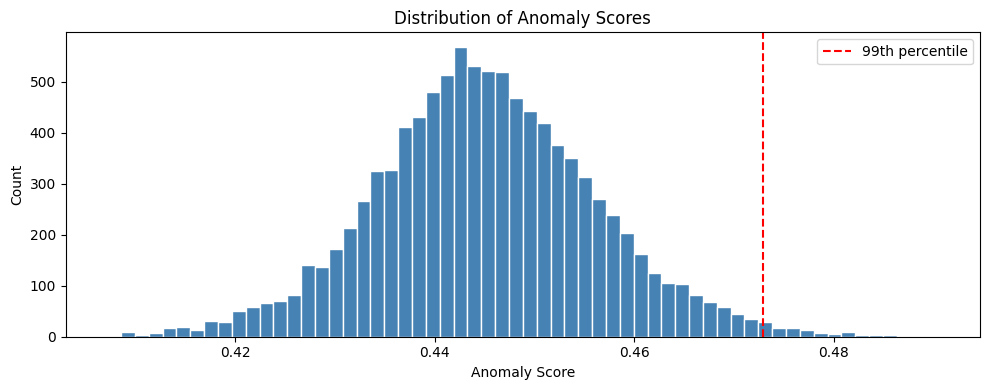

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(scores, bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.axvline(np.percentile(scores, 99), color="red", linestyle="--", label="99th percentile")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
contamination = y.mean()  # actual fraud rate in this dataset (~0.0017)
threshold = np.percentile(scores, 100 * (1 - contamination))
df["is_anomaly"] = scores > threshold
print(f"Contamination rate used: {contamination:.4%}")
print(f"Threshold: {threshold:.4f}")
print(f"Flagged as anomalies: {df['is_anomaly'].sum()}")

Contamination rate used: 0.2300%
Threshold: 0.4803
Flagged as anomalies: 23


In [15]:
anomalies = df[df["is_anomaly"] == True].sort_values("anomaly_score", ascending=False)
print(f"Total anomalies: {len(anomalies)}")
print(anomalies.head(20))

Total anomalies: 23
            Time         V1         V2         V3        V4         V5  \
150680   93879.0 -12.833631   7.508790 -20.491952  7.465780 -11.575304   
59490    48864.0  -1.590486   0.992415  -0.512841  1.120752  -1.916756   
47206    43132.0  -6.718658  -5.919701   0.289137  3.390498  -3.050636   
5322      5227.0  -0.059452  -3.579822   0.048555 -0.448273  -2.618167   
77838    57239.0  -1.835769   0.173395   2.082502  1.363253  -1.014903   
133364   80354.0  -7.410554  -2.878063  -0.802336  2.593668  -0.317436   
47802    43369.0  -3.365319   2.426503  -3.752227  0.276017  -2.305870   
189158  128283.0   0.348691  -3.752105  -3.647055 -0.200626  -0.777774   
226814  144808.0  -2.405207   2.943823  -7.616654  3.533374  -5.417494   
226416  144617.0  -3.290224  -0.922621   0.689205 -2.178702   2.240684   
188976  128216.0 -10.887231 -12.367005  -2.399214  0.055331  -5.932579   
26432    34063.0  -1.864081  -0.529195  -4.001003  1.086002 -20.839996   
199447  132971.0  

In [16]:
normal = df[df["is_anomaly"] == False]
anomal = df[df["is_anomaly"] == True]

comparison = pd.DataFrame({
    "normal_mean":  normal[feature_cols].mean(numeric_only=True),
    "anomaly_mean": anomal[feature_cols].mean(numeric_only=True),
})

comparison["diff_%"] = ((comparison["anomaly_mean"] - comparison["normal_mean"])
                        / comparison["normal_mean"].abs().replace(0, np.nan) * 100).round(1)

comparison.sort_values("diff_%", ascending=False)

,normal_mean,anomaly_mean,diff_%
V13,0.000168,0.264330,157546.3
V7,-0.002621,0.528378,20257.4
V11,0.005423,0.457786,8341.9
V6,-0.015502,1.152979,7537.4
V24,0.004646,0.242043,5110.1
V21,-0.005151,0.191681,3821.5
V4,-0.031193,0.625933,2106.7
Amount,83.794716,874.860000,944.1
V15,0.017092,0.134974,689.7
V19,-0.016954,0.052385,409.0


Average Precision (PR-AUC): 0.1168
(random baseline for this class balance ≈ 0.0023)

Confusion matrix at chosen threshold (rows=actual, cols=predicted):
[[9957   20]
 [  20    3]]

              precision    recall  f1-score   support

      normal     0.9980    0.9980    0.9980      9977
       fraud     0.1304    0.1304    0.1304        23

    accuracy                         0.9960     10000
   macro avg     0.5642    0.5642    0.5642     10000
weighted avg     0.9960    0.9960    0.9960     10000



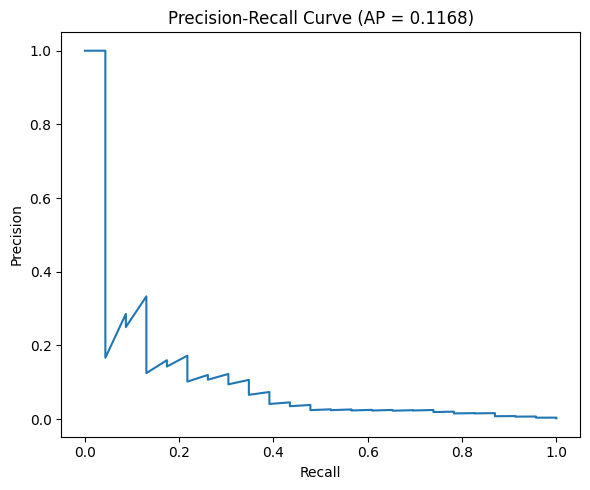

In [17]:
ap_score = average_precision_score(y, scores)
print(f"Average Precision (PR-AUC): {ap_score:.4f}")
print(f"(random baseline for this class balance ≈ {y.mean():.4f})\n")

print("Confusion matrix at chosen threshold (rows=actual, cols=predicted):")
print(confusion_matrix(y, df["is_anomaly"].astype(int)))
print()
print(classification_report(y, df["is_anomaly"].astype(int), target_names=["normal", "fraud"], digits=4))

precision, recall, thresholds = precision_recall_curve(y, scores)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.4f})")
plt.tight_layout()
plt.show()
